## Aprendizado bayesiano na prática

A implementação desse aprendizado é bastante simples, tanto para treinamento quanto para a realização de previsões. No exemplo a seguir, é possível verificar a utilização do algoritmo Naive Bayes em uma conhecida base de dados, chamada Iris Dataset, para o processo de classificação do gênero da planta Iris:

- Mapa mental do tema: [1-ensinando-um-sistema-aprender.md](../../../docs/mapas-mentais/01-aprendizado-de-maquina-overview/1-ensinando-um-sistema-aprender.md)

- A documentação pode ser acessada no link: https://scikit-learn.org/stable/modules/naive_bayes.html
- Iris Dataset pode ser acessada em: <https://archive.ics.uci.edu/ml/datasets/iris>


Este pipeline mostra um fluxo básico de aprendizado de máquina supervisionado aplicado ao conjunto de dados Iris. O objetivo é treinar um classificador na base de treino e depois usar esse modelo para prever as classes da base de validação.

- `load_iris`: carrega o conjunto de dados Iris, que contém medidas de sépalas e pétalas de três espécies de Iris. As variáveis de entrada `X` são as características e `y` são os rótulos de classe.
- `train_test_split`: divide os dados em duas partes, uma para treinamento (`X_train`, `y_train`) e outra para validação (`X_test`, `y_test`). Aqui o conjunto de teste tem 50% dos dados.

Para deixar mais claro, usei uma amostra real do Iris Dataset. Cada registro contém as medidas de sépala e pétala em centímetros, seguidas da classe da flor (0=setosa, 1=versicolor, 2=virginica). Exemplo de instâncias:

- [5.1, 3.5, 1.4, 0.2] → classe 0
- [7.0, 3.2, 4.7, 1.4] → classe 1
- [6.3, 3.3, 6.0, 2.5] → classe 2

Modelo:
- `GaussianNB` é uma implementação do classificador Naive Bayes para dados contínuos assumindo distribuição normal (gaussiana) das características.
- Naive Bayes é um método probabilístico que usa o teorema de Bayes para calcular a probabilidade de cada classe dado um conjunto de atributos.
- A palavra “naive” vem da hipótese de independência condicional: supõe-se que cada atributo contribui de forma independente para a probabilidade da classe, dado o rótulo. Em muitos casos essa hipótese simplifica o modelo e ainda produz boas classificações.

Como funciona:
- Durante o treinamento, `gnb.fit(X_train, y_train)` estima, para cada classe, a média e a variância de cada atributo seguindo a hipótese gaussiana.
- Ao prever, `gnb.predict(X_test)` calcula a probabilidade de cada classe para cada amostra de teste, usando as densidades gaussianas das características, e escolhe a classe mais provável.

Por que usar `GaussianNB`:
- É simples, rápido e costuma funcionar bem com conjuntos de dados pequenos e bem comportados.
- É um ótimo exemplo acadêmico por ser fácil de explicar e por mostrar claramente o uso de um modelo probabilístico em classificação.

No contexto deste notebook, o pipeline ilustra:
- carregamento de dados,
- separação entre treino e teste,
- definição do modelo,
- treinamento com exemplos rotulados,
- produção de previsões em dados novos.

## Índice

1. `Importando as bibliotecas`
2. `Importando o modelo Naive Bayes`
3. `Carregando os dados`
4. `Separando a base de treino da validação`
5. `Criando o classificador`
6. `Treinando o classificador`
7. `Realizando as previsões`
8. `Avaliação e interpretação dos resultados`
    - `Tabela comparando verdadeiros x preditos`
    - `Mostrar as primeiras linhas`
    - `Métricas`
    - `Matriz de confusão visual`
    - `Exemplos classificados incorretamente`

## 1. Instalação de dependências
Execute esta célula se os pacotes ainda não estiverem instalados no ambiente.

In [ ]:
#!pip install --quiet  scikit-learn pandas matplotlib seaborn scipy

## Importando as bibliotecas

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

## Importando o modelo Naive Bayes

In [2]:
from sklearn.naive_bayes import GaussianNB

## Carregando os dados

In [3]:
X, y = load_iris(return_X_y=True)

## Separando a base de treino da validação

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

## Criando o classificador

In [6]:
gnb = GaussianNB()

## Treinando o classificador

In [7]:
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Realizando as previsões

In [8]:
y_pred = gnb.predict(X_test)

# Avaliação e interpretação dos resultados

Neste trecho de código, vamos avaliar o desempenho do classificador treinado sobre a base de teste (`X_test`, `y_test`) e documentar os resultados de forma clara.

## Importação das Libs

### Bibliotecas usadas

- `pandas`:
    - cria um `DataFrame` tabular com as amostras de teste e os rótulos.
    - facilita a visualização dos dados, comparação entre verdadeiros e preditos, e seleção de exemplos.
- `seaborn`:
    - cria um gráfico de matriz de confusão mais legível e esteticamente agradável.
- `sklearn.metrics`:
    - `accuracy_score`: calcula a acurácia do modelo.
    - `classification_report`: gera métricas por classe como precisão, recall e F1-score.
    - `confusion_matrix`: cria a matriz de confusão.
- `matplotlib.pyplot`:
    - exibe o gráfico gerado pelo `seaborn`.

In [11]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt

### O que acontece no código?

1. Cria-se um `DataFrame` chamado `df_result` com as quatro características de `X_test`:
     - `sepal_length`
     - `sepal_width`
     - `petal_length`
     - `petal_width`
2. Adiciona-se ao `DataFrame`:
     - `y_true`: rótulos reais da base de teste.
     - `y_pred`: valores previstos pelo modelo.
     - `correct`: um valor booleano indicando se a previsão foi correta.
3. Exibe-se as primeiras linhas do `DataFrame` para inspecionar exemplos e verificar resultados.

## Tabela comparando verdadeiros x preditos e primeiras amostras

In [12]:
cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df_result = pd.DataFrame(X_test, columns=cols)
df_result['y_true'] = y_test
df_result['y_pred'] = y_pred
df_result['correct'] = df_result['y_true'] == df_result['y_pred']

## Mostrar as primeiras linhas (ajuste a quantidade se desejar)

In [13]:
display(df_result.head(20))

,sepal_length,sepal_width,petal_length,petal_width,y_true,y_pred,correct
0,5.8,2.8,5.1,2.4,2,2,True
1,6.0,2.2,4.0,1.0,1,1,True
2,5.5,4.2,1.4,0.2,0,0,True
3,7.3,2.9,6.3,1.8,2,2,True
4,5.0,3.4,1.5,0.2,0,0,True
5,6.3,3.3,6.0,2.5,2,2,True
6,5.0,3.5,1.3,0.3,0,0,True
7,6.7,3.1,4.7,1.5,1,1,True
8,6.8,2.8,4.8,1.4,1,1,True
9,6.1,2.8,4.0,1.3,1,1,True


### Métricas

- `Accuracy`:
    - é a proporção de previsões corretas em relação ao total de amostras.
    - no contexto do código, indica o desempenho geral do modelo no conjunto de teste.
- `Classification report`:
    - mostra métricas por classe:
        - `precision` (precisão): entre as amostras previstas como classe X, quantas realmente pertencem a X.
        - `recall` (sensibilidade): entre as amostras que são realmente da classe X, quantas foram previstas corretamente.
        - `f1-score`: média harmônica entre precisão e recall.
        - `support`: número de amostras reais de cada classe.
    - é útil para entender se o modelo se comporta bem em todas as classes ou se há alguma classe com desempenho ruim.

In [15]:
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.3f}\n')
print('Classification report:')
print(classification_report(y_test, y_pred, digits=3))

Accuracy: 0.947

Classification report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        21
           1      0.882     1.000     0.938        30
           2      1.000     0.833     0.909        24

    accuracy                          0.947        75
   macro avg      0.961     0.944     0.949        75
weighted avg      0.953     0.947     0.946        75



## Matriz de confusão visual

### Matriz de confusão

- A matriz de confusão compara rótulos verdadeiros (`Verdadeiro`) com rótulos previstos (`Predito`).
- Cada célula `(i, j)` indica quantas amostras da classe `i` foram classificadas como classe `j`.
- A diagonal principal mostra os acertos; valores fora da diagonal mostram erros de classificação.
- No gráfico, essa matriz é representada como um mapa de calor (`heatmap`), facilitando a visualização de onde o modelo erra.

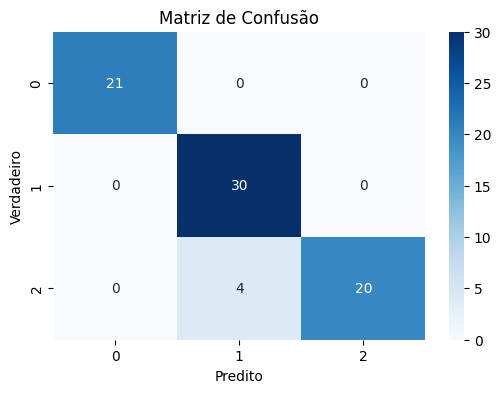

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

### Última parte do código

- Imprime-se uma lista de exemplos classificados incorretamente.
- Isso ajuda a identificar casos específicos em que o modelo não funcionou bem, permitindo análise qualitativa das falhas.

Esse bloco de código transforma os resultados do modelo em relatórios numéricos e visuais para facilitar a interpretação do seu desempenho.

In [18]:
print('\nExemplos classificados incorretamente:')
display(df_result.loc[~df_result['correct']].reset_index(drop=True))


Exemplos classificados incorretamente:


,sepal_length,sepal_width,petal_length,petal_width,y_true,y_pred,correct
0,6.1,2.6,5.6,1.4,2,1,False
1,6.0,2.2,5.0,1.5,2,1,False
2,6.3,2.8,5.1,1.5,2,1,False
3,4.9,2.5,4.5,1.7,2,1,False
